In [42]:
# =================================================================
# 01_baseline_training_and_evaluation — Rainfall + Urban Features
# Research question: Does adding impervious surface context improve
# urban pluvial flood prediction beyond rainfall alone?
#
# Features: 7 rainfall intensity windows + urban_percentage (8 total)
# Models: Random Forest | XGBoost | Logistic Regression | SVC
# Class imbalance handling: class_weight='balanced' / scale_pos_weight
# =================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.ensemble         import RandomForestClassifier
from sklearn.linear_model     import LogisticRegression
from sklearn.svm              import SVC
from sklearn.preprocessing    import StandardScaler
from sklearn.model_selection  import GroupShuffleSplit
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score,
)

# ── 1. CONFIGURATION ──────────────────────────────────────────────
LIGHTWEIGHT_PATH       = r"D:\Development\RESEARCH\urban_flood_database\chronicle\unified_ml_dataset_LIGHTWEIGHT.pkl"
URBAN_THRESHOLD        = 20.0
THRESH_1H              = 7.0
THRESH_24H             = 1.0
PFDI_PLUVIAL_THRESHOLD = 1.0

# ── BALANCE STRATEGY ──────────────────────────────────────────────
# 'class_weight' : train on full X_train; models use class_weight='balanced'
#                  (or scale_pos_weight for XGBoost)
# 'undersample'  : train on X_train_bal built in the ratio-exploration cell;
#                  no class weighting inside models
BALANCE_METHOD = 'undersample'

# 7 rainfall intensity features + urban_percentage (normalized — safe across
# polygon sizes). urban_built_up_area_m2 (absolute) is intentionally excluded.
FEATURE_COLS = [
    '30_max_rainfall_intens',  '60_max_rainfall_intens',
    '120_max_rainfall_intens', '240_max_rainfall_intens',
    '360_max_rainfall_intens', '720_max_rainfall_intens',
    '1440_max_rainfall_intens',
    'urban_percentage',
]

# ── 2. LOAD & FILTER ──────────────────────────────────────────────
print("Loading lightweight dataset...")
df = pd.read_pickle(LIGHTWEIGHT_PATH)

filtered_df = df[
    (df['urban_percentage']         >= URBAN_THRESHOLD) &
    (df['60_max_rainfall_intens']   >  THRESH_1H) &
    (df['1440_max_rainfall_intens'] >  THRESH_24H) &
    (df['PFDI_p99']                 <  PFDI_PLUVIAL_THRESHOLD)
].copy()

filtered_df['original_basin_id'] = (
    filtered_df['event_id'].apply(lambda x: str(x).split('_noflood_')[0])
)

n_flood    = (filtered_df['is_flood'] == 1).sum()
n_no_flood = (filtered_df['is_flood'] == 0).sum()
print(f"\nDataset after filtering: {len(filtered_df):,} samples")
print(f"  Flood (1):    {n_flood:,}  ({n_flood/len(filtered_df)*100:.1f}%)")
print(f"  No-flood (0): {n_no_flood:,}  ({n_no_flood/len(filtered_df)*100:.1f}%)")

# ── 3. FEATURES & SPLIT ───────────────────────────────────────────
feature_cols = [c for c in FEATURE_COLS if c in filtered_df.columns]
X      = filtered_df[feature_cols]
y      = filtered_df['is_flood']
groups = filtered_df['original_basin_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"\nTrain: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Features ({len(feature_cols)}): {feature_cols}")

# ── 4. SCALED VERSIONS (for Logistic Regression and SVC) ─────────
# Fit scaler on train only — prevents data leakage into test set
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("StandardScaler fitted on training set.")

Loading lightweight dataset...

Dataset after filtering: 45,131 samples
  Flood (1):    32,685  (72.4%)
  No-flood (0): 12,446  (27.6%)

Train: 35,337 | Test: 9,794
Features (8): ['30_max_rainfall_intens', '60_max_rainfall_intens', '120_max_rainfall_intens', '240_max_rainfall_intens', '360_max_rainfall_intens', '720_max_rainfall_intens', '1440_max_rainfall_intens', 'urban_percentage']
StandardScaler fitted on training set.


In [43]:
# ── EVALUATION HELPERS ────────────────────────────────────────────

def evaluate_model(name, y_true, y_pred, split='Test'):
    """Print classification report and return a metrics dict."""
    print(f"\n── {name} [{split}] ─────────────────────────────────────────")
    print(classification_report(y_true, y_pred, target_names=['No Flood', 'Flood']))
    return {
        'Model':        name,
        'Split':        split,
        'Flood Prec.':  precision_score(y_true, y_pred, pos_label=1),
        'Flood Recall': recall_score(y_true, y_pred, pos_label=1),
        'Flood F1':     f1_score(y_true, y_pred, pos_label=1),
        'No-Flood F1':  f1_score(y_true, y_pred, pos_label=0),
    }


def plot_model(name, y_train_true, y_train_pred, y_test_true, y_test_pred,
               cmap, feat_imp_df=None):
    """Train and test confusion matrices side by side, plus optional feature importance."""
    n_plots = 3 if feat_imp_df is not None else 2
    fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5))
    fig.suptitle(f'{name} — Train vs Test', fontsize=14, fontweight='bold')

    ConfusionMatrixDisplay(
        confusion_matrix(y_train_true, y_train_pred),
        display_labels=['No Flood', 'Flood']
    ).plot(ax=axes[0], cmap=cmap, colorbar=False)
    axes[0].set_title('Train — Confusion Matrix')
    axes[0].grid(False)

    ConfusionMatrixDisplay(
        confusion_matrix(y_test_true, y_test_pred),
        display_labels=['No Flood', 'Flood']
    ).plot(ax=axes[1], cmap=cmap, colorbar=False)
    axes[1].set_title('Test — Confusion Matrix')
    axes[1].grid(False)

    if feat_imp_df is not None:
        sns.barplot(data=feat_imp_df, x='Importance', y='Feature',
                    ax=axes[2], palette='viridis')
        axes[2].set_title('Feature Importance')
        axes[2].set_xlabel('Relative Importance')
        axes[2].set_ylabel('')

    plt.tight_layout()
    plt.show()


# ── DIAGNOSTIC HELPERS ────────────────────────────────────────────

from sklearn.metrics  import log_loss as sk_log_loss
from sklearn.pipeline import Pipeline


def compute_learning_curve(model, X_tr, y_tr, X_te, y_te,
                            n_points=8, max_samples=None, random_state=42):
    """
    Train clones of model on stratified subsets of increasing size,
    evaluate on the full fixed X_te each time.
    max_samples: cap the largest subset (useful for slow models like SVC).
    Returns (sizes, train_f1s, test_f1s).
    """
    from sklearn.base import clone

    y_arr_tr = np.array(y_tr)
    y_arr_te = np.array(y_te)
    idx_pos  = np.where(y_arr_tr == 1)[0]
    idx_neg  = np.where(y_arr_tr == 0)[0]
    rng = np.random.default_rng(random_state)
    rng.shuffle(idx_pos); rng.shuffle(idx_neg)

    if max_samples is not None:
        ratio   = len(idx_pos) / len(y_arr_tr)
        idx_pos = idx_pos[:int(max_samples * ratio)]
        idx_neg = idx_neg[:int(max_samples * (1 - ratio))]

    def _get(X, idx):
        return X.iloc[idx] if hasattr(X, 'iloc') else X[idx]

    sizes, tr_f1s, te_f1s = [], [], []
    for frac in np.linspace(0.1, 1.0, n_points):
        n_p = max(int(len(idx_pos) * frac), 2)
        n_n = max(int(len(idx_neg) * frac), 2)
        idx = np.concatenate([idx_pos[:n_p], idx_neg[:n_n]])

        m = clone(model)
        m.fit(_get(X_tr, idx), y_arr_tr[idx])

        tr_f1s.append(f1_score(y_arr_tr, m.predict(X_tr)))
        te_f1s.append(f1_score(y_arr_te, m.predict(X_te)))
        sizes.append(n_p + n_n)

    return np.array(sizes), np.array(tr_f1s), np.array(te_f1s)


def plot_diagnostics(name, color, lc_sizes, lc_train, lc_test,
                     loss_train=None, loss_test=None, loss_xlabel='Iteration'):
    """
    Plot loss curve (if provided) and learning curve side by side.
    loss_train/loss_test: list of per-iteration loss values (optional).
    """
    has_loss = loss_train is not None
    n_plots  = 2 if has_loss else 1
    fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5))
    fig.suptitle(f'{name} — Diagnostics', fontsize=14, fontweight='bold')
    if n_plots == 1:
        axes = [axes]

    if has_loss:
        ax = axes[0]
        ax.plot(loss_train, color=color,    lw=2,          label='Train')
        ax.plot(loss_test,  color='tomato', lw=2, ls='--', label='Test')
        ax.set_xlabel(loss_xlabel)
        ax.set_ylabel('Log-loss')
        ax.set_title('Loss Curve')
        ax.legend()

    ax = axes[-1]
    ax.plot(lc_sizes, lc_train, 'o-',  color=color,   lw=2, label='Train F1 (Flood)')
    ax.plot(lc_sizes, lc_test,  's--', color='tomato', lw=2, label='Test F1 (Flood)')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('F1 Score')
    ax.set_title('Learning Curve')
    ax.legend()
    ax.set_ylim([0, 1])

    plt.tight_layout()
    plt.show()

print("Helper functions loaded.")

Helper functions loaded.


  1:1 → Flood F1=0.799 | No-Flood F1=0.520
  2:1 → Flood F1=0.846 | No-Flood F1=0.433
  3:1 → Flood F1=0.844 | No-Flood F1=0.421
  5:1 → Flood F1=0.844 | No-Flood F1=0.421
  10:1 → Flood F1=0.844 | No-Flood F1=0.421

── Ratio Exploration Results ────────────────────────────────
       Train Flood  Train No-Flood  Flood F1  No-Flood F1  No-Flood Recall  No-Flood Precision
Ratio                                                                                         
1:1           9185            9185     0.799        0.520            0.461               0.598
2:1          18370            9185     0.846        0.433            0.278               0.975
3:1          26152            9185     0.844        0.421            0.268               0.977
5:1          26152            9185     0.844        0.421            0.268               0.977
10:1         26152            9185     0.844        0.421            0.268               0.977


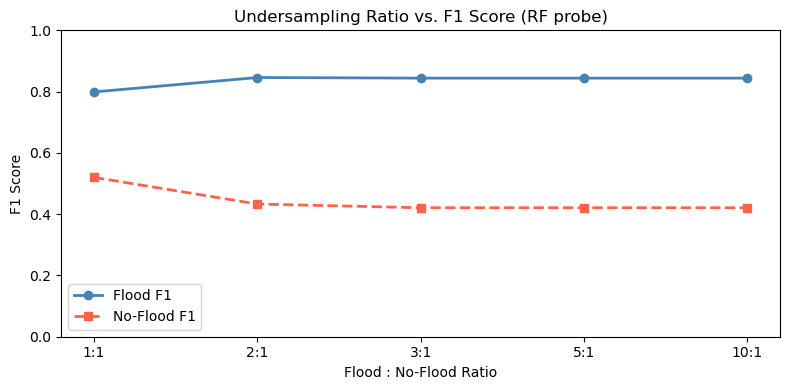

In [44]:
# ── UNDERSAMPLING RATIO EXPLORATION ──────────────────────────────
# Goal: find the flood:no-flood ratio that gives the best trade-off
# between Flood F1 and No-Flood F1.
# We probe with RF only (fastest model) across 5 candidate ratios.

from sklearn.utils import resample

RATIOS_TO_TEST = [1, 2, 3, 5, 10]  # flood:no-flood multiplier

n_no_flood_train = (y_train == 0).sum()
n_flood_train    = (y_train == 1).sum()
probe_results    = []

for ratio in RATIOS_TO_TEST:
    n_flood_keep = min(n_no_flood_train * ratio, n_flood_train)

    # Separate classes in training set
    X_fl = X_train[y_train == 1];  y_fl = y_train[y_train == 1]
    X_nf = X_train[y_train == 0];  y_nf = y_train[y_train == 0]

    # Randomly undersample the flood class (no replacement)
    X_fl_down, y_fl_down = resample(
        X_fl, y_fl, replace=False, n_samples=n_flood_keep, random_state=42
    )

    X_tr_bal = pd.concat([X_fl_down, X_nf])
    y_tr_bal = pd.concat([y_fl_down, y_nf])

    # RF probe — no class_weight needed, data is already balanced by design
    probe = RandomForestClassifier(
        n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
    )
    probe.fit(X_tr_bal, y_tr_bal)
    y_pred_probe = probe.predict(X_test)

    probe_results.append({
        'Ratio':              f'{ratio}:1',
        'Train Flood':        n_flood_keep,
        'Train No-Flood':     n_no_flood_train,
        'Flood F1':           round(f1_score(y_test, y_pred_probe, pos_label=1), 3),
        'No-Flood F1':        round(f1_score(y_test, y_pred_probe, pos_label=0), 3),
        'No-Flood Recall':    round(recall_score(y_test, y_pred_probe, pos_label=0), 3),
        'No-Flood Precision': round(precision_score(y_test, y_pred_probe, pos_label=0), 3),
    })
    print(f"  {ratio}:1 → Flood F1={probe_results[-1]['Flood F1']:.3f} | "
          f"No-Flood F1={probe_results[-1]['No-Flood F1']:.3f}")

ratio_df = pd.DataFrame(probe_results).set_index('Ratio')
print("\n── Ratio Exploration Results ────────────────────────────────")
print(ratio_df.to_string())

# Plot Flood F1 vs No-Flood F1 across ratios
fig, ax = plt.subplots(figsize=(8, 4))
ratios_labels = [r['Ratio'] for r in probe_results]
ax.plot(ratios_labels, [r['Flood F1']    for r in probe_results],
        'o-',  color='steelblue', lw=2, label='Flood F1')
ax.plot(ratios_labels, [r['No-Flood F1'] for r in probe_results],
        's--', color='tomato',    lw=2, label='No-Flood F1')
ax.set_xlabel('Flood : No-Flood Ratio')
ax.set_ylabel('F1 Score')
ax.set_title('Undersampling Ratio vs. F1 Score (RF probe)')
ax.legend()
ax.set_ylim([0, 1])
plt.tight_layout()
plt.show()


In [45]:
# ── SET CHOSEN RATIO & BUILD BALANCED TRAINING SET ────────────────
# Adjust UNDERSAMPLE_RATIO based on the plot above before running models.
UNDERSAMPLE_RATIO = 1  # flood:no-flood

n_flood_keep = min(n_no_flood_train * UNDERSAMPLE_RATIO, n_flood_train)
X_fl_down, y_fl_down = resample(
    X_train[y_train == 1], y_train[y_train == 1],
    replace=False, n_samples=n_flood_keep, random_state=42
)
X_train_bal = pd.concat([X_fl_down, X_train[y_train == 0]])
y_train_bal = pd.concat([y_fl_down, y_train[y_train == 0]])

# Scaled version for LR and SVC (use scaler already fitted on full X_train)
X_train_bal_scaled = scaler.transform(X_train_bal)

print(f"\nBalanced training set (ratio {UNDERSAMPLE_RATIO}:1):")
print(f"  Flood:    {(y_train_bal == 1).sum():,}")
print(f"  No-Flood: {(y_train_bal == 0).sum():,}")
print(f"  Total:    {len(y_train_bal):,}")

# ── ROUTE: set shared variables used by all model cells ───────────
# Xtr / ytr    : training features/labels passed to model.fit()
# Xtr_scaled   : scaled version (for LR and SVC)
# _cw          : class_weight argument for sklearn models (None = no weighting)
if BALANCE_METHOD == 'undersample':
    Xtr, ytr   = X_train_bal,        y_train_bal
    Xtr_scaled = X_train_bal_scaled
    _cw        = None
else:  # 'class_weight'
    Xtr, ytr   = X_train,        y_train
    Xtr_scaled = X_train_scaled
    _cw        = 'balanced'

print(f"\nBalance mode : '{BALANCE_METHOD}'")
print(f"Training on  : {len(ytr):,} samples")
print(f"  Flood      : {(ytr == 1).sum():,}  ({(ytr == 1).mean()*100:.1f}%)")
print(f"  No-Flood   : {(ytr == 0).sum():,}  ({(ytr == 0).mean()*100:.1f}%)")
print(f"  _cw        : {_cw}")


Balanced training set (ratio 1:1):
  Flood:    9,185
  No-Flood: 9,185
  Total:    18,370

Balance mode : 'undersample'
Training on  : 18,370 samples
  Flood      : 9,185  (50.0%)
  No-Flood   : 9,185  (50.0%)
  _cw        : None


In [46]:
filtered_df

,uuid,event_id,start_time,end_time,duration_days,area_km2,urban_built_up_area_m2,urban_percentage,centroid_lon,centroid_lat,...,120_max_rainfall_intens,240_max_rainfall_intens,360_max_rainfall_intens,720_max_rainfall_intens,1440_max_rainfall_intens,imerg_type,is_flood,PFDI_max,PFDI_p95,original_basin_id
14,8c9a3dc419614cab9cf13efa51a4b2e8,310,960508800.0,960595200.0,2,0.509424,109864.0,21.566335,1.768654,41.534826,...,17.817500,12.633750,9.093333,4.834583,2.432708,final,1,0.971391,0.643377,310
26,1616737983c24ad1a60791eb31411e32,322,960508800.0,960595200.0,2,0.647051,173276.0,26.779344,1.828742,41.504440,...,19.390000,13.255000,9.430000,5.047083,2.539375,final,1,35.166646,0.020855,322
28,56db0c30236140d3b8d1e2761d04c541,324,960595200.0,960595200.0,1,0.161886,48772.0,30.127452,1.559152,41.300291,...,19.557499,12.297500,8.216666,4.252083,2.135625,final,1,0.278889,0.159368,324
48,e30dadc9232f46c3b439ffa7394d2314,344,960595200.0,960595200.0,1,0.897993,226209.0,25.190499,1.904098,41.520763,...,19.390000,13.255000,9.430000,5.047083,2.539375,final,1,2.820693,0.264852,344
58,c5703fb36ca8436298532e5385eb3c48,354,960595200.0,960681600.0,2,6.762940,1886648.0,27.896862,2.031005,41.339790,...,9.915000,6.332500,5.354167,2.697500,1.364583,final,1,0.360240,0.097225,354
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
884657,4cc243be-c18e-407c-b139-e05d8fb72059,846687_noflood_20250610_20250613_noflood_20250610,2025-06-10 00:00:00,2025-06-13 00:00:00,4,104.645090,28606900.0,27.337069,-103.330806,20.591999,...,11.352500,10.016250,8.029166,4.396667,2.198333,final_no_flood,0,3.797949,0.000775,846687
884662,1279f39b-6710-4ae6-8511-179335b98da1,846687_noflood_20250702_20250705_noflood_20250702,2025-07-02 00:00:00,2025-07-05 00:00:00,4,104.645090,28606900.0,27.337069,-103.330806,20.591999,...,7.222500,5.154375,4.020000,3.025833,1.675312,final_no_flood,0,3.797949,0.000775,846687
884663,7d6c2c41-4b80-4dec-8820-e269a7f0c30b,846687_noflood_20250627_20250630_noflood_20250627,2025-06-27 00:00:00,2025-06-30 00:00:00,4,104.645090,28606900.0,27.337069,-103.330806,20.591999,...,7.222500,5.154375,4.020000,3.025833,1.675312,final_no_flood,0,3.797949,0.000775,846687
884664,e55bfb88-928c-4651-a818-420ffb5671c8,846687_noflood_20250807_20250810_noflood_20250807,2025-08-07 00:00:00,2025-08-10 00:00:00,4,104.645090,28606900.0,27.337069,-103.330806,20.591999,...,6.011250,4.728750,3.572083,1.960208,1.041771,final_no_flood,0,3.797949,0.000775,846687


Training Random Forest...

── Random Forest [Train] ─────────────────────────────────────────
              precision    recall  f1-score   support

    No Flood       0.86      0.68      0.76      9185
       Flood       0.73      0.89      0.80      9185

    accuracy                           0.78     18370
   macro avg       0.80      0.78      0.78     18370
weighted avg       0.80      0.78      0.78     18370


── Random Forest [Test] ─────────────────────────────────────────
              precision    recall  f1-score   support

    No Flood       0.60      0.46      0.52      3261
       Flood       0.76      0.85      0.80      6533

    accuracy                           0.72      9794
   macro avg       0.68      0.65      0.66      9794
weighted avg       0.70      0.72      0.71      9794



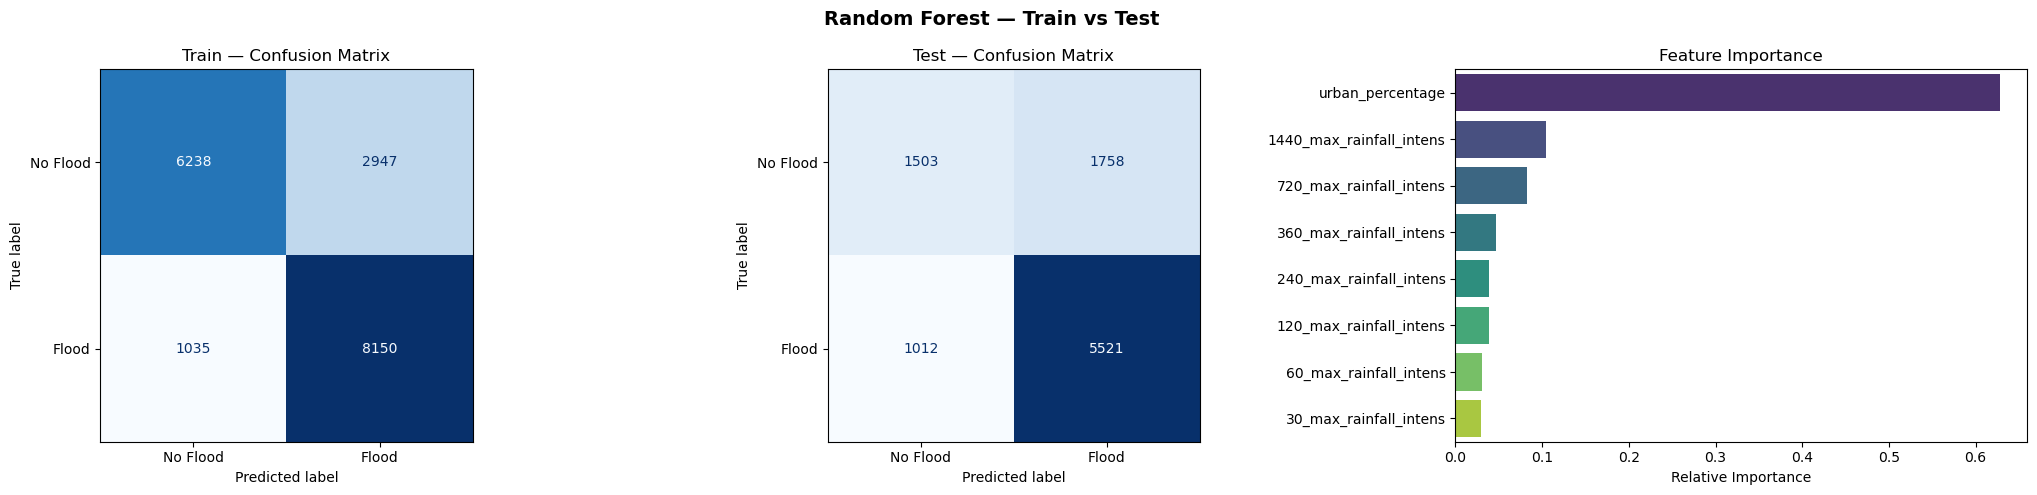

Computing staged log-loss (train & test)...
Computing learning curve...


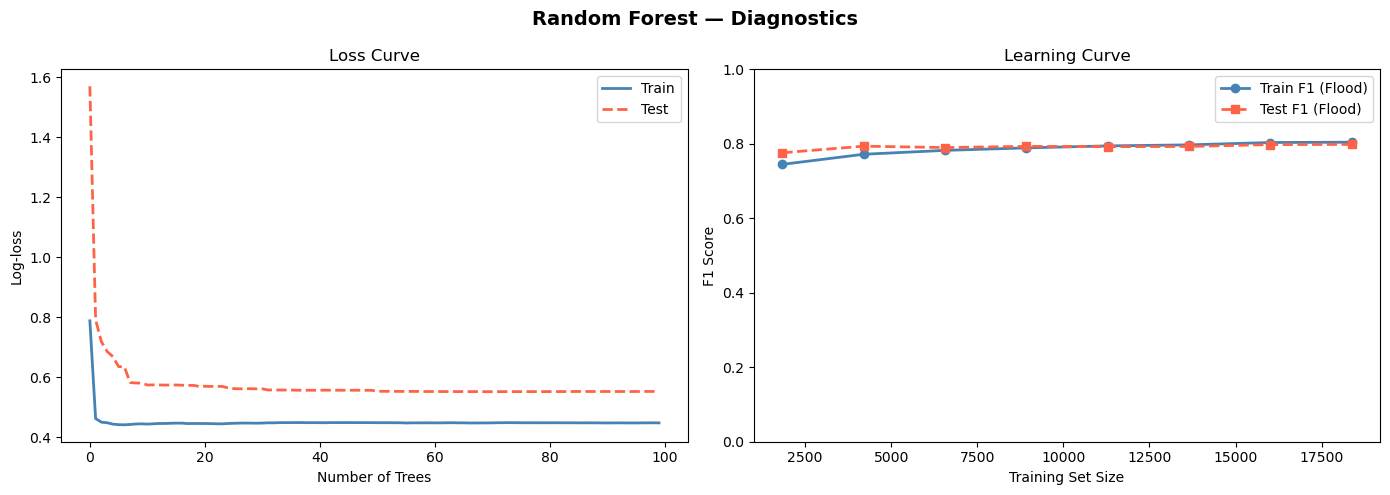

In [47]:
# ── MODEL 1: RANDOM FOREST ────────────────────────────────────────
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight=_cw,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(Xtr, ytr)

y_pred_rf_train = rf_model.predict(Xtr)
y_pred_rf       = rf_model.predict(X_test)

metrics_rf_train = evaluate_model('Random Forest', ytr,    y_pred_rf_train, split='Train')
metrics_rf_test  = evaluate_model('Random Forest', y_test, y_pred_rf,       split='Test')

feat_imp_rf = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': rf_model.feature_importances_,
}).sort_values('Importance', ascending=False)

plot_model('Random Forest', ytr, y_pred_rf_train, y_test, y_pred_rf,
           cmap='Blues', feat_imp_df=feat_imp_rf)

# ── Loss curve: cumulative log-loss as trees are added ────────────
# RF has no staged_predict_proba — we manually accumulate each tree's output.
print("Computing staged log-loss (train & test)...")
Xtr_arr = Xtr.values if hasattr(Xtr, 'values') else Xtr
Xte_arr = X_test.values if hasattr(X_test, 'values') else X_test
y_arr_tr = np.array(ytr);  y_arr_te = np.array(y_test)

proba_sum_tr = np.zeros(len(y_arr_tr))
proba_sum_te = np.zeros(len(y_arr_te))
rf_loss_train, rf_loss_test = [], []

for i, tree in enumerate(rf_model.estimators_):
    proba_sum_tr += tree.predict_proba(Xtr_arr)[:, 1]
    proba_sum_te += tree.predict_proba(Xte_arr)[:, 1]
    rf_loss_train.append(sk_log_loss(y_arr_tr, proba_sum_tr / (i + 1)))
    rf_loss_test.append(sk_log_loss(y_arr_te,  proba_sum_te / (i + 1)))

# ── Learning curve ────────────────────────────────────────────────
print("Computing learning curve...")
lc_sizes_rf, lc_train_rf, lc_test_rf = compute_learning_curve(
    rf_model, Xtr, ytr, X_test, y_test, n_points=8
)

plot_diagnostics('Random Forest', 'steelblue',
                 lc_sizes_rf, lc_train_rf, lc_test_rf,
                 loss_train=rf_loss_train, loss_test=rf_loss_test,
                 loss_xlabel='Number of Trees')

Class counts — Flood: 9,185 | No-Flood: 9,185 | scale_pos_weight: 1.0000
Training XGBoost...

── XGBoost [Train] ─────────────────────────────────────────
              precision    recall  f1-score   support

    No Flood       0.87      0.88      0.87      9185
       Flood       0.88      0.86      0.87      9185

    accuracy                           0.87     18370
   macro avg       0.87      0.87      0.87     18370
weighted avg       0.87      0.87      0.87     18370


── XGBoost [Test] ─────────────────────────────────────────
              precision    recall  f1-score   support

    No Flood       0.59      0.42      0.49      3261
       Flood       0.75      0.85      0.80      6533

    accuracy                           0.71      9794
   macro avg       0.67      0.64      0.65      9794
weighted avg       0.70      0.71      0.70      9794



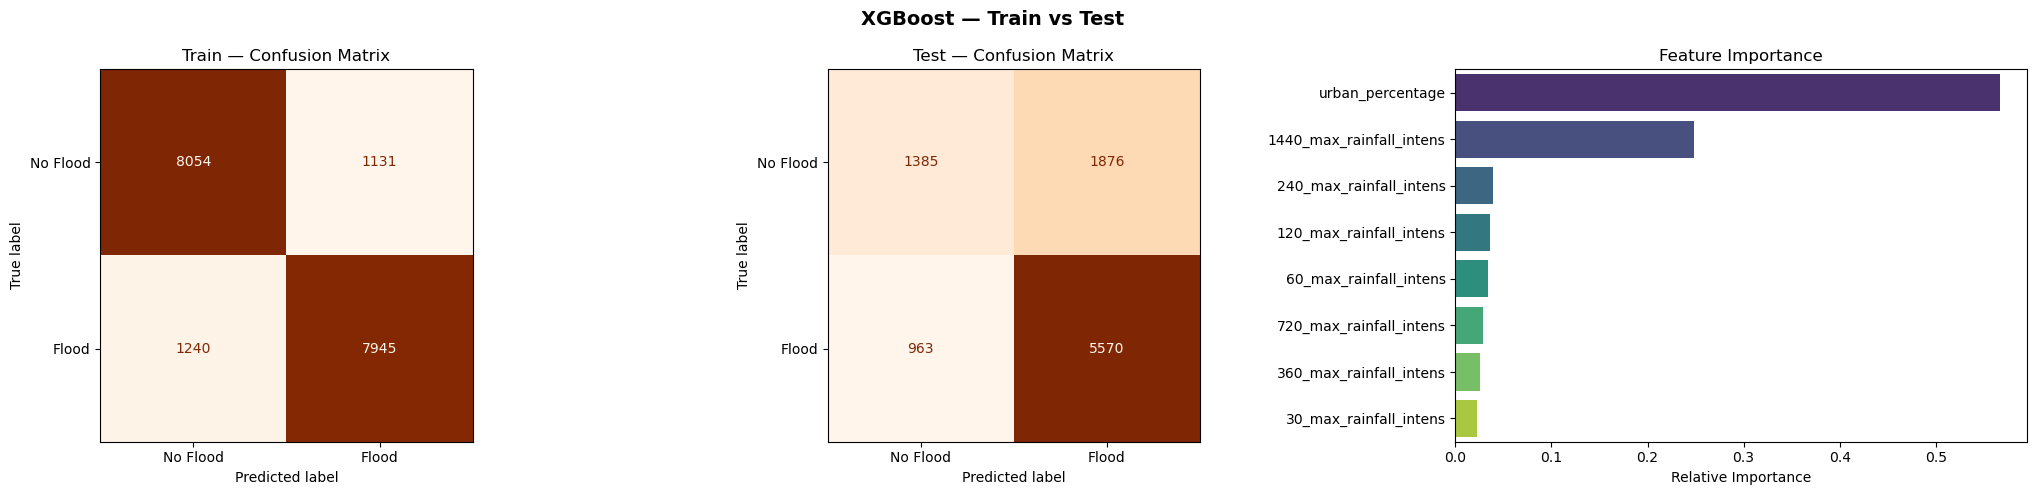

Computing learning curve...


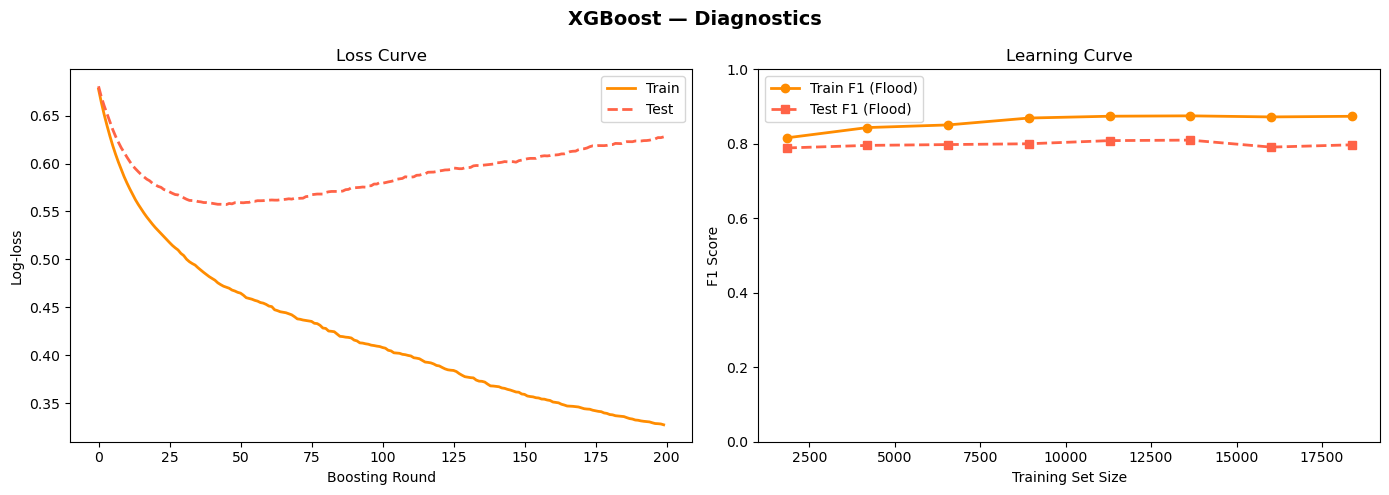

In [48]:
# ── MODEL 2: XGBOOST ──────────────────────────────────────────────
# scale_pos_weight is derived from Xtr: ~0.38 in class_weight mode (full
# imbalanced train), ~1.0 in undersample mode (already balanced).
n_neg = (ytr == 0).sum()
n_pos = (ytr == 1).sum()
_spw  = n_neg / n_pos
print(f"Class counts — Flood: {n_pos:,} | No-Flood: {n_neg:,} | scale_pos_weight: {_spw:.4f}")

print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=_spw,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1,
)
# eval_set exposes per-round train/test log-loss for the loss curve
xgb_model.fit(Xtr, ytr,
              eval_set=[(Xtr, ytr), (X_test, y_test)],
              verbose=False)

y_pred_xgb_train = xgb_model.predict(Xtr)
y_pred_xgb       = xgb_model.predict(X_test)

metrics_xgb_train = evaluate_model('XGBoost', ytr,    y_pred_xgb_train, split='Train')
metrics_xgb_test  = evaluate_model('XGBoost', y_test, y_pred_xgb,       split='Test')

feat_imp_xgb = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': xgb_model.feature_importances_,
}).sort_values('Importance', ascending=False)

plot_model('XGBoost', ytr, y_pred_xgb_train, y_test, y_pred_xgb,
           cmap='Oranges', feat_imp_df=feat_imp_xgb)

# ── Loss curve: native logloss per boosting round ─────────────────
results        = xgb_model.evals_result()
xgb_loss_train = results['validation_0']['logloss']
xgb_loss_test  = results['validation_1']['logloss']

# ── Learning curve ────────────────────────────────────────────────
print("Computing learning curve...")
lc_sizes_xgb, lc_train_xgb, lc_test_xgb = compute_learning_curve(
    xgb_model, Xtr, ytr, X_test, y_test, n_points=8
)

plot_diagnostics('XGBoost', 'darkorange',
                 lc_sizes_xgb, lc_train_xgb, lc_test_xgb,
                 loss_train=xgb_loss_train, loss_test=xgb_loss_test,
                 loss_xlabel='Boosting Round')

Training Logistic Regression...

── Logistic Regression [Train] ─────────────────────────────────────────
              precision    recall  f1-score   support

    No Flood       0.69      0.59      0.64      9185
       Flood       0.64      0.74      0.69      9185

    accuracy                           0.66     18370
   macro avg       0.67      0.66      0.66     18370
weighted avg       0.67      0.66      0.66     18370


── Logistic Regression [Test] ─────────────────────────────────────────
              precision    recall  f1-score   support

    No Flood       0.52      0.54      0.53      3261
       Flood       0.76      0.75      0.76      6533

    accuracy                           0.68      9794
   macro avg       0.64      0.64      0.64      9794
weighted avg       0.68      0.68      0.68      9794



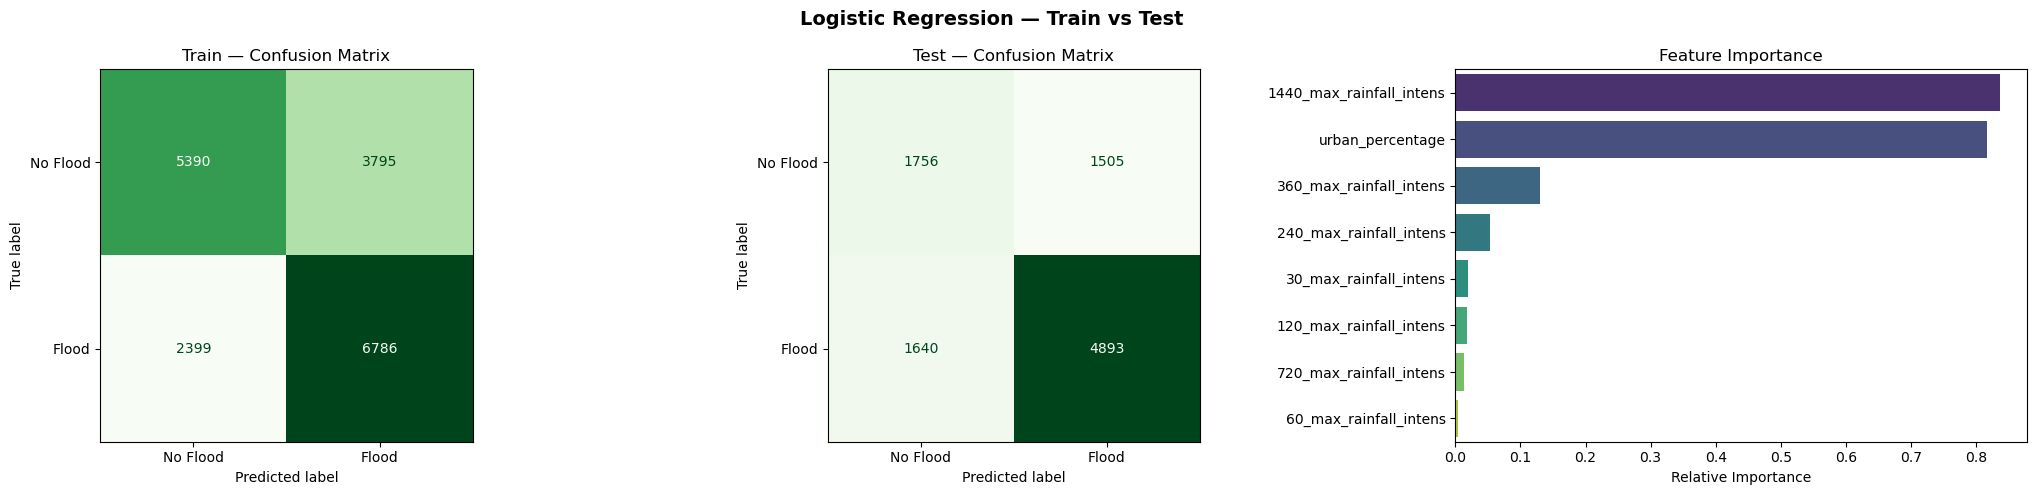

Computing learning curve...


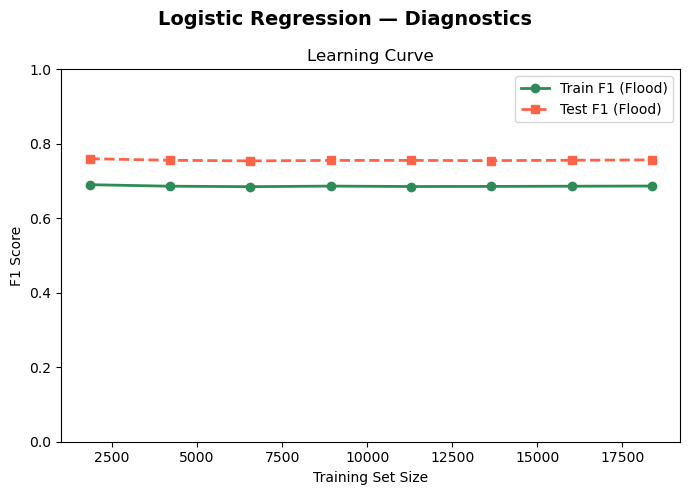

In [49]:
# ── MODEL 3: LOGISTIC REGRESSION ─────────────────────────────────
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, class_weight=_cw, random_state=42)
lr_model.fit(Xtr_scaled, ytr)

y_pred_lr_train = lr_model.predict(Xtr_scaled)
y_pred_lr       = lr_model.predict(X_test_scaled)

metrics_lr_train = evaluate_model('Logistic Regression', ytr,    y_pred_lr_train, split='Train')
metrics_lr_test  = evaluate_model('Logistic Regression', y_test, y_pred_lr,       split='Test')

coef_df = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': np.abs(lr_model.coef_[0]),
}).sort_values('Importance', ascending=False)

plot_model('Logistic Regression', ytr, y_pred_lr_train, y_test, y_pred_lr,
           cmap='Greens', feat_imp_df=coef_df)

# ── Learning curve (Pipeline prevents scaler leakage) ─────────────
# LR has no iterative loss — it converges to a unique minimum.
print("Computing learning curve...")
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, class_weight=_cw, random_state=42)),
])
lc_sizes_lr, lc_train_lr, lc_test_lr = compute_learning_curve(
    lr_pipe, Xtr, ytr, X_test, y_test, n_points=8
)

plot_diagnostics('Logistic Regression', 'seagreen',
                 lc_sizes_lr, lc_train_lr, lc_test_lr)

Training SVC (this may take a moment on CPU)...

── SVC (RBF) [Train] ─────────────────────────────────────────
              precision    recall  f1-score   support

    No Flood       0.85      0.47      0.60      9185
       Flood       0.63      0.92      0.75      9185

    accuracy                           0.69     18370
   macro avg       0.74      0.69      0.67     18370
weighted avg       0.74      0.69      0.67     18370


── SVC (RBF) [Test] ─────────────────────────────────────────
              precision    recall  f1-score   support

    No Flood       0.70      0.40      0.51      3261
       Flood       0.75      0.92      0.83      6533

    accuracy                           0.74      9794
   macro avg       0.73      0.66      0.67      9794
weighted avg       0.74      0.74      0.72      9794



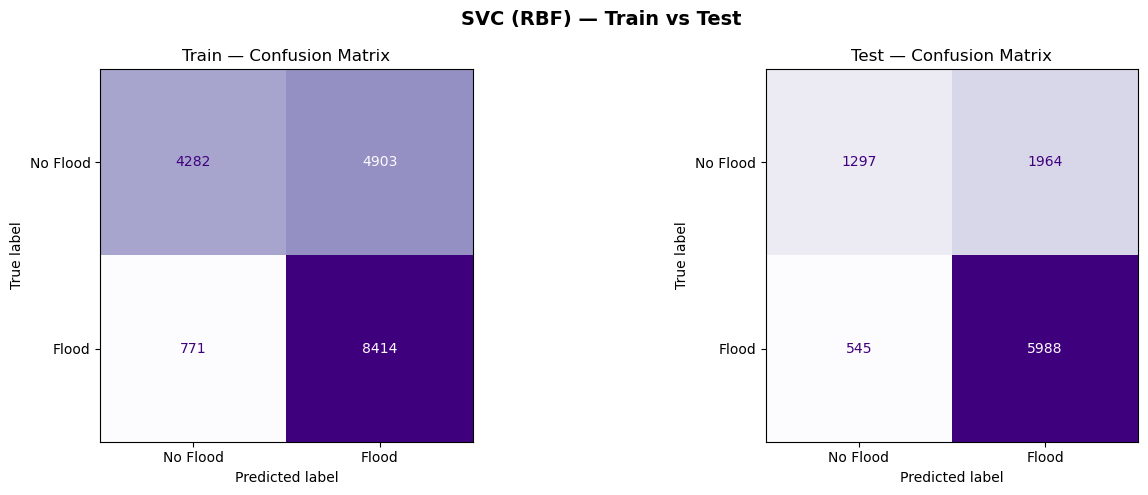

Computing learning curve (capped at 5,000 samples for speed)...


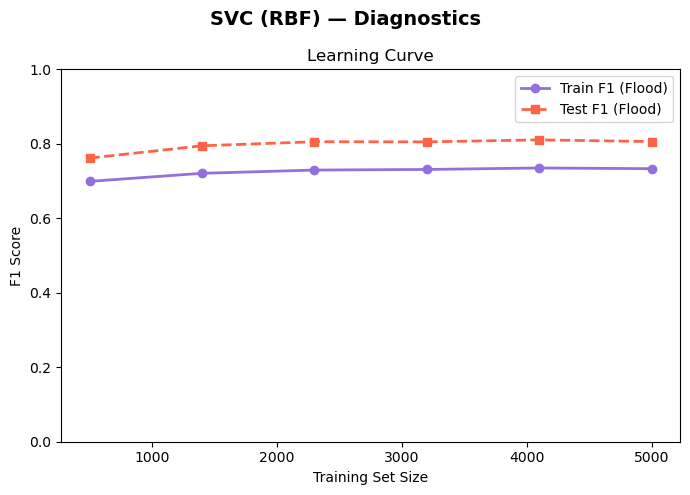

In [50]:
# ── MODEL 4: SVC (RBF KERNEL) ─────────────────────────────────────
# No feature importance available for RBF kernel.
print("Training SVC (this may take a moment on CPU)...")
svc_model = SVC(kernel='rbf', class_weight=_cw, random_state=42)
svc_model.fit(Xtr_scaled, ytr)

y_pred_svc_train = svc_model.predict(Xtr_scaled)
y_pred_svc       = svc_model.predict(X_test_scaled)

metrics_svc_train = evaluate_model('SVC (RBF)', ytr,    y_pred_svc_train, split='Train')
metrics_svc_test  = evaluate_model('SVC (RBF)', y_test, y_pred_svc,       split='Test')

plot_model('SVC (RBF)', ytr, y_pred_svc_train, y_test, y_pred_svc,
           cmap='Purples')

# ── Learning curve (Pipeline + capped at 5k samples for speed) ────
# SVC is O(n²) — capping avoids multi-minute runtimes.
# SVC has no iterative loss.
print("Computing learning curve (capped at 5,000 samples for speed)...")
svc_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    SVC(kernel='rbf', class_weight=_cw, random_state=42)),
])
lc_sizes_svc, lc_train_svc, lc_test_svc = compute_learning_curve(
    svc_pipe, Xtr, ytr, X_test, y_test,
    n_points=6, max_samples=5000
)

plot_diagnostics('SVC (RBF)', 'mediumpurple',
                 lc_sizes_svc, lc_train_svc, lc_test_svc)

In [51]:
# ── MODEL COMPARISON (Train vs Test) ──────────────────────────────
all_metrics = [
    metrics_rf_train,  metrics_rf_test,
    metrics_xgb_train, metrics_xgb_test,
    metrics_lr_train,  metrics_lr_test,
    metrics_svc_train, metrics_svc_test,
]
comparison = (
    pd.DataFrame(all_metrics)
    .set_index(['Model', 'Split'])
    .round(3)
)

print("── Train vs Test Comparison ─────────────────────────────────")
print(comparison.to_string())

# Overfitting gap: Train Flood F1 − Test Flood F1
gap_df = comparison['Flood F1'].unstack('Split')[['Train', 'Test']].copy()
gap_df['Gap (Train−Test)'] = (gap_df['Train'] - gap_df['Test']).round(3)
print("\n── Flood F1 Overfitting Gap ─────────────────────────────────")
print(gap_df.to_string())

── Train vs Test Comparison ─────────────────────────────────
                           Flood Prec.  Flood Recall  Flood F1  No-Flood F1
Model               Split                                                  
Random Forest       Train        0.734         0.887     0.804        0.758
                    Test         0.758         0.845     0.799        0.520
XGBoost             Train        0.875         0.865     0.870        0.872
                    Test         0.748         0.853     0.797        0.494
Logistic Regression Train        0.641         0.739     0.687        0.635
                    Test         0.765         0.749     0.757        0.528
SVC (RBF)           Train        0.632         0.916     0.748        0.601
                    Test         0.753         0.917     0.827        0.508

── Flood F1 Overfitting Gap ─────────────────────────────────
Split                Train   Test  Gap (Train−Test)
Model                                              
Logistic Re